In [385]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.external_data_encyclopedia import ExternalDataEncyclopedia
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.refinement_plus.inspect_tools import InspectTools

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

ed = ExternalDataEncyclopedia(
    external_data_path=Path(r"C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\external_data")
)

In [386]:
exports_folder = Path("dp_export_tests")
areas_export_path: Path = exports_folder / "00_add_areas"
clean_db_export_path: Path = exports_folder / "01_cleanup_db"
spectral_export_path: Path = exports_folder / "02_add_spectral"

In [387]:
df = pl.scan_parquet(spectral_export_path / "reconb")

df.filter(pl.col("i") == 100).collect()

i,j,face,band depth 350,band depth 440,slope 1000,ratio 1000,sigma band depth 350,sigma band depth 440,sigma slope 1000,sigma ratio 1000
u32,u32,enum,f32,f32,f32,f32,f32,f32,f32,f32
100,0,"""negx""",-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0
100,1,"""negx""",-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0
100,2,"""negx""",-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0
100,3,"""negx""",-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0
100,4,"""negx""",-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0
…,…,…,…,…,…,…,…,…,…,…
100,8187,"""posz""",-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0
100,8188,"""posz""",-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0
100,8189,"""posz""",-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0


In [388]:
import numpy as np
import cv2
from numpy.typing import NDArray


def cubemap_to_equirectangular(
    faces: dict[str, NDArray],
    output_resolution: tuple[int, int]
) -> NDArray:
    """
    Inverse of PANToCubemap.sample_face_roi_simple_super_sample()

    Input faces must use the same convention:
        posx: ( 1, V,-U)
        negx: (-1, V, U)
        posy: ( U, 1,-V)
        negy: ( U,-1, V)
        posz: ( U, V, 1)
        negz: (-U, V,-1)

    output_resolution:
        (width,height)

    Supports:
        HxW
        HxWxC
    """

    out_w, out_h = output_resolution

    face0 = faces["posx"]

    if face0.ndim == 2:
        result = np.empty(
            (out_h, out_w),
            dtype=face0.dtype
        )
    else:
        result = np.empty(
            (out_h, out_w, face0.shape[2]),
            dtype=face0.dtype
        )


    # -----------------------------
    # Equirectangular pixel grid
    # -----------------------------

    px = np.arange(out_w, dtype=np.float32)
    py = np.arange(out_h, dtype=np.float32)

    X, Y = np.meshgrid(px, py)


    # Same convention as forward:
    #
    # lon = atan2(x,z)
    # lat = asin(y)

    lon = (X / (out_w - 1) - 0.5) * 2 * np.pi
    lat = (0.5 - Y / (out_h - 1)) * np.pi


    # longitude/latitude -> direction vector

    dir_x = np.cos(lat) * np.sin(lon)
    dir_y = np.sin(lat)
    dir_z = np.cos(lat) * np.cos(lon)


    ax = np.abs(dir_x)
    ay = np.abs(dir_y)
    az = np.abs(dir_z)


    def sample_face(name, U, V, mask):

        if not np.any(mask):
            return

        h, w = faces[name].shape[:2]

        # [-1,1] -> pixel coordinates
        mapx = ((U + 1) * 0.5) * (w - 1)
        mapy = ((V + 1)  * 0.5) * (h - 1)

        sampled = cv2.remap(
            faces[name],
            mapx.astype(np.float32),
            mapy.astype(np.float32),
            interpolation=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_WRAP
        )

        result[mask] = sampled[mask]


    eps = 1e-8


    # -----------------------------
    # +X
    # -----------------------------

    mask = (
        (ax >= ay) &
        (ax >= az) &
        (dir_x > 0)
    )

    U = -dir_z / np.maximum(ax, eps)
    V =  dir_y / np.maximum(ax, eps)

    sample_face("posx", U, V, mask)



    # -----------------------------
    # -X
    # -----------------------------

    mask = (
        (ax >= ay) &
        (ax >= az) &
        (dir_x <= 0)
    )

    U = dir_z / np.maximum(ax, eps)
    V = dir_y / np.maximum(ax, eps)

    sample_face("negx", U, V, mask)



    # -----------------------------
    # +Y
    # -----------------------------

    mask = (
        (ay >= ax) &
        (ay >= az) &
        (dir_y > 0)
    )

    U = dir_x / np.maximum(ay, eps)
    V = -dir_z / np.maximum(ay, eps)

    sample_face("posy", U, V, mask)



    # -----------------------------
    # -Y
    # -----------------------------

    mask = (
        (ay >= ax) &
        (ay >= az) &
        (dir_y <= 0)
    )

    U = dir_x / np.maximum(ay, eps)
    V = dir_z / np.maximum(ay, eps)

    sample_face("negy", U, V, mask)



    # -----------------------------
    # +Z
    # -----------------------------

    mask = (
        (az >= ax) &
        (az >= ay) &
        (dir_z > 0)
    )

    U = dir_x / np.maximum(az, eps)
    V = dir_y / np.maximum(az, eps)

    sample_face("posz", U, V, mask)



    # -----------------------------
    # -Z
    # -----------------------------

    mask = (
        (az >= ax) &
        (az >= ay) &
        (dir_z <= 0)
    )

    U = -dir_x / np.maximum(az, eps)
    V = dir_y / np.maximum(az, eps)

    sample_face("negz", U, V, mask)


    return result

In [389]:
_faces: Dict[str, np.ndarray] = InspectTools.extract_column_as_faces(df, "band depth 350")

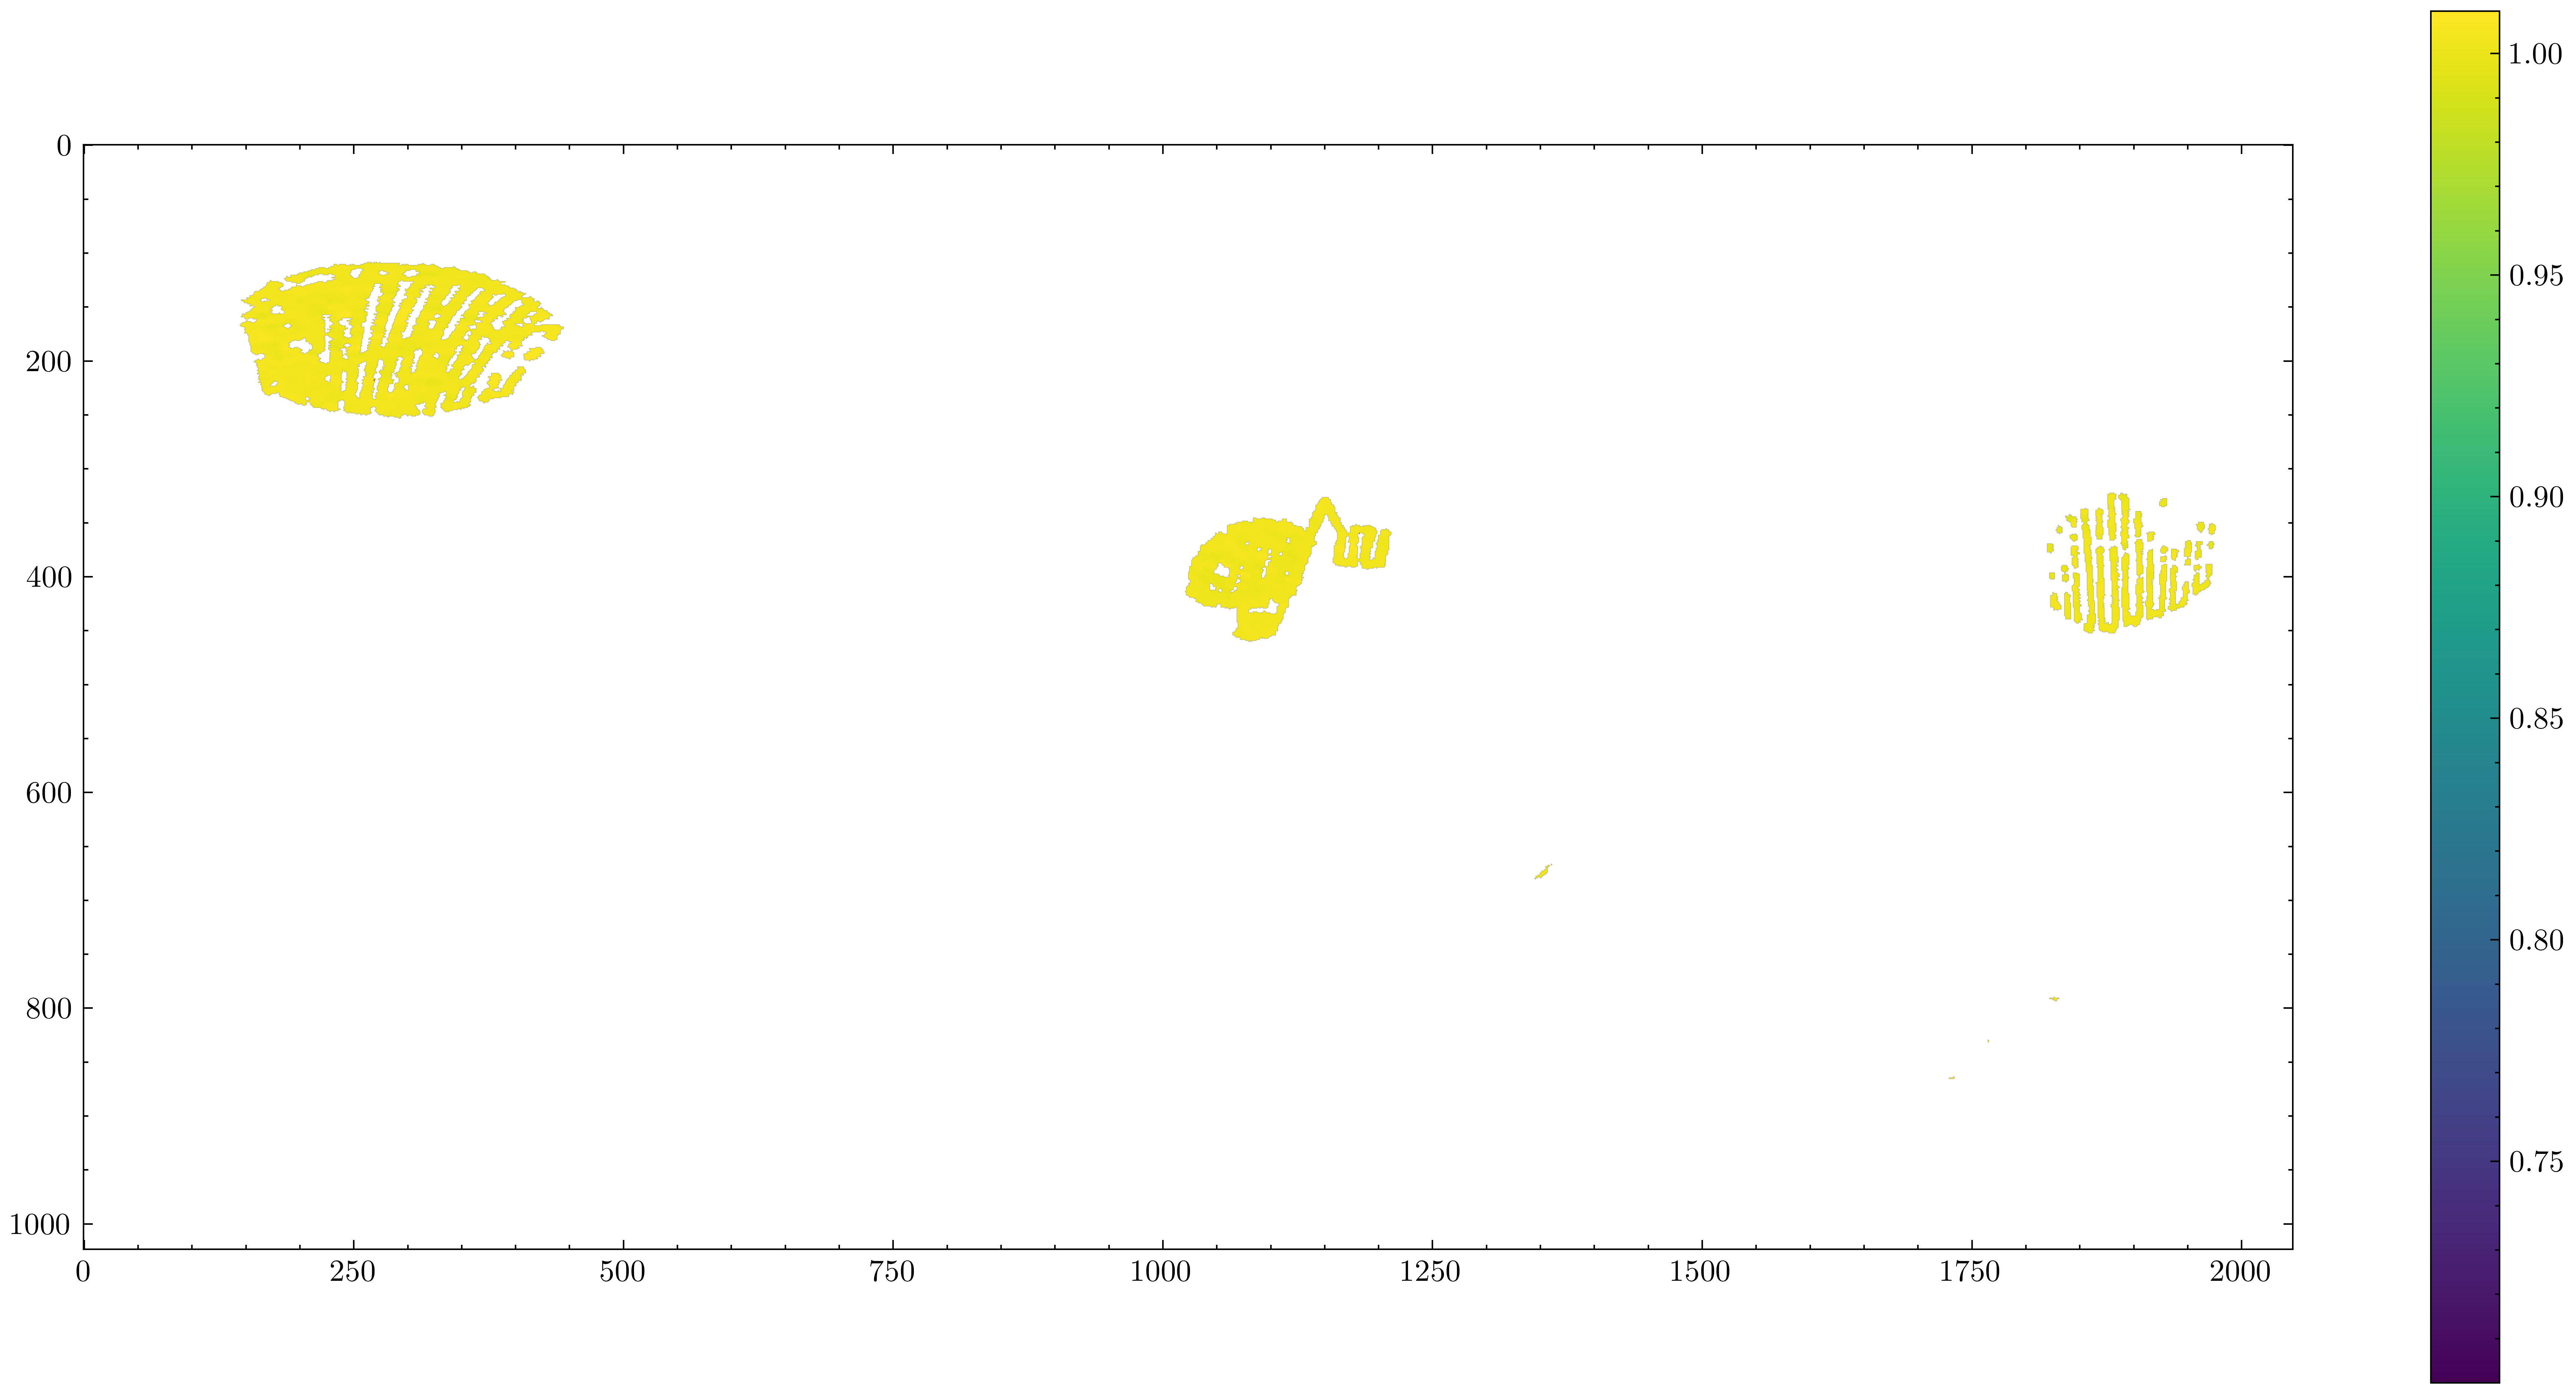

In [ ]:
faces = {k: v[:,:] for k,v in _faces.items()}


pan = InspectTools.cubemap_to_equirectangular(
    faces=faces,
    output_resolution=(2048, 1024)
)

pan[pan < 0.4] = np.nan

vals = df.filter(pl.col("band depth 350") != -9999.0).collect()["band depth 350"]
min, max = vals.min(), vals.max()

plt.figure(figsize=(16, 8))
plt.imshow(pan, vmin=min, v_max = max)
plt.colorbar()
plt.show()

In [391]:
# pan = InspectTools.extract_column_as_equirectangular(
#     df, "y", output_resolution=(2048, 1024)
# )

# plt.figure(figsize=(16, 8))
# plt.imshow(np.clip(pan, -1, 1))
# plt.colorbar()
# plt.show()

In [392]:
# pan = InspectTools.extract_column_as_equirectangular(
#     df, "area", output_resolution=(2048, 1024)
# )

# plt.figure(figsize=(16, 8))
# plt.imshow(pan, cmap="gray")
# plt.axis("off")
# plt.show()